# ROI Selection NB

Here, our goal is to define the parking area boundaries using the regions surrounded by the red points shown in the image, and to detect their coordinates.

The coordinates will be the corner points of the green parking areas.

Of course, we could do this without programming by taking this image and using another program, such as AutoCAD, to find the coordinates of the relevant points. In that case, we would set the top-left corner of the image as `(0, 0)` and read the coordinates from there.

However, in this project, we will follow a programmatic approach.

Thanks to the script we create below, the coordinates of the points we click on will be displayed. We can first learn how the process works through this notebook, and then run the same logic as a script from a `.py` file.

Instead of using the normal terminal, open the terminal with **Anaconda Prompt**. Then, go to the project folder and run the following command:

```bash
python roi_selection.py
```

After running this command, an image frame from the related video will open. When we click on points using the mouse, the coordinates of those clicked points will be captured.

The coordinates of the selected points will be shown in the terminal.

In this project, the camera angle must remain fixed so that the parking lane areas do not change.

In this project, the work was done only for the parking areas on the right side. In a similar way, the project can also be extended for the parking areas on the left side.

The `python roi_selection.py` file should be run from the terminal. Then, the points should be selected as shown below, and their coordinates should be collected from the terminal.


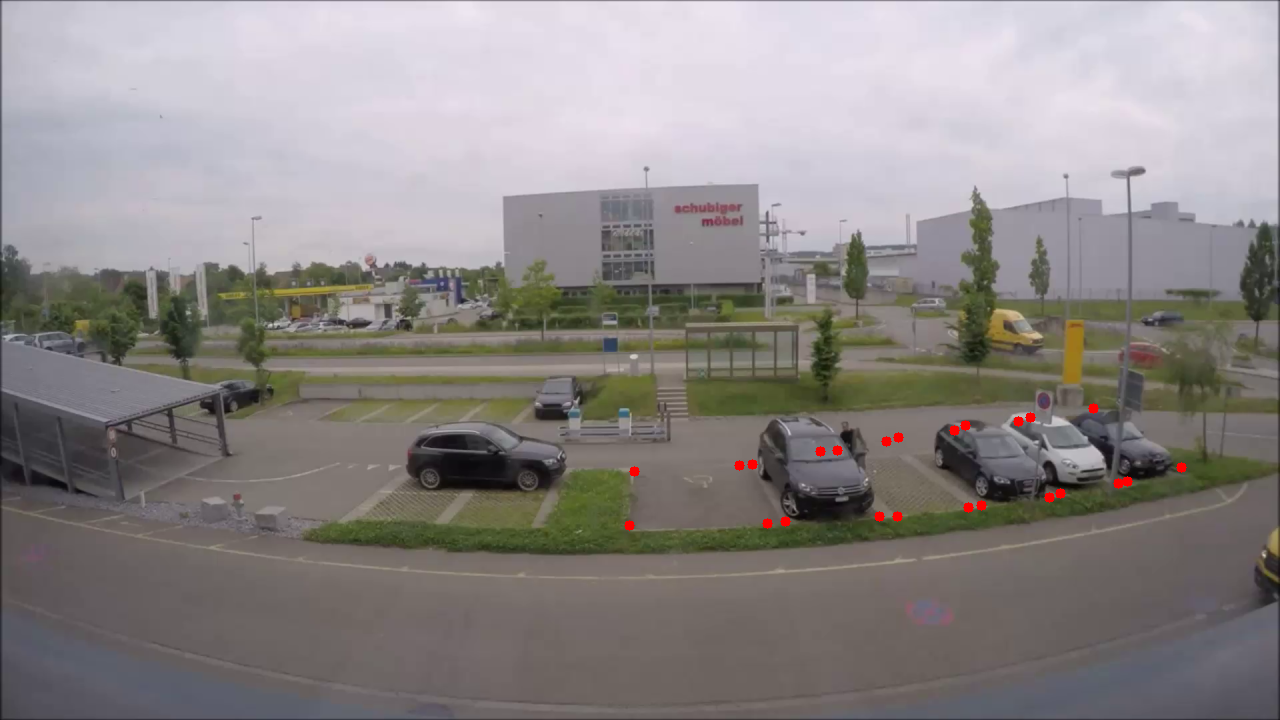

## 1. Importing the Required Libraries

In [ ]:
import cv2  # OpenCV for image processing

import imutils  # For helper functions such as resizing

import numpy as np  # Although it is not used directly in this code, it is commonly included in computer vision projects

## 2. Global Variables


In [ ]:
# A global list used to store the (x, y) coordinates of the points
# we click with the mouse.

points = []

# Font type that can be used to write text on the screen.
# It is not actively used in this code.
font = cv2.FONT_HERSHEY_SIMPLEX

## 3. Video and Reference Frame Preparation


In [ ]:
video_path = "inference/test.mp4"
cap = cv2.VideoCapture(video_path)

In [ ]:
# [EXPERT NOTE] There is NO loop here.
# Our goal is not to play the video, but only to take one reference frame,
# which is the image we will use to select the polygons.

ret, frame = cap.read()

# We resize the reference frame to the same size used in our main project
# which is the parking lot detection/counting code.
# Here, the width is set to 1280.

# This ensures that the coordinates we select here will be 100% compatible
# with the main project.

frame = imutils.resize(frame, width=1280)

## 4. Preparing the Window and Mouse Movement Callback


In [ ]:
window_name = "ROI"  # The name of the window where the image will be displayed

cv2.namedWindow(window_name)  # Create an empty window with this name

In [ ]:
# [MAIN LOGIC] The function that will capture mouse movements.
# This is called a callback function.

# This function is called automatically by OpenCV.
# event: Shows which mouse event occurred, such as left click, right click, movement, etc.
# x, y: The current coordinates of the mouse
# flags, param: Additional parameters, not used in this code

def mouse_callback(event, x, y, flags, param):
    
    # If the event is "left mouse button down" (EVENT_LBUTTONDOWN):
    if event == cv2.EVENT_LBUTTONDOWN:
        
        # Add the clicked point's (x, y) coordinates to the `points` list
        points.append((x, y))
        
        # [FOR THE DEVELOPER] Print the coordinates to the console.
        # We will copy and use these outputs to create the polygons
        # in the parking lot detection code.
        
        print("x:{} y:{}".format(x, y))
        
        # --- Visual Feedback ---
        
        # Draw circles on the frame so that the user can see where they clicked.
        # This loop redraws all points in the list after each click.
        
        for i in range(len(points) - 1):
            # Draw a red circle on the i-th point
            cv2.circle(frame, points[i], 5, (0, 0, 255), -1)
            
            # Draw a red circle on the (i+1)-th point
            cv2.circle(frame, points[i+1], 5, (0, 0, 255), -1)
            
            # The commented-out code below could optionally be used
            # to write the coordinates directly on the screen.
            # cv2.putText(frame, str(points[i]), points[i], font, 0.5, (0,0,255), 2)
            # cv2.putText(frame, str(points[i+1]), points[i+1], font, 0.5, (0,0,255), 2)
            
        # Show the updated `frame`, now with the circles drawn on it,
        # again in the window.
        cv2.imshow(window_name, frame)

# [CRITICAL CONNECTION]
# We tell OpenCV:
# "If any mouse event happens inside the window named `window_name` ('ROI'),
# call the `mouse_callback` function."

cv2.setMouseCallback(window_name, mouse_callback)

## 5. Display Loop


In [ ]:
while True:
    # Continuously display the `frame`, which is our reference frame, on the screen.
    # As the `mouse_callback` function updates this `frame`,
    # meaning as it draws circles on it,
    # this loop displays the updated version.

    cv2.imshow(window_name, frame)

    # Wait for a keyboard key to be pressed for 1 millisecond.
    key = cv2.waitKey(1)

    # If the pressed key is `ESC`, whose ASCII code is 27:
    if key == 27:

        # Before exiting, save the final version of the frame,
        # including the points we drew on it,
        # to disk as `roi-1.png`.
        # This is useful for remembering the selected points later.

        cv2.imwrite("roi-1.png", frame)
        break  # Exit the loop

ROI.png dosyası görüntüsü:
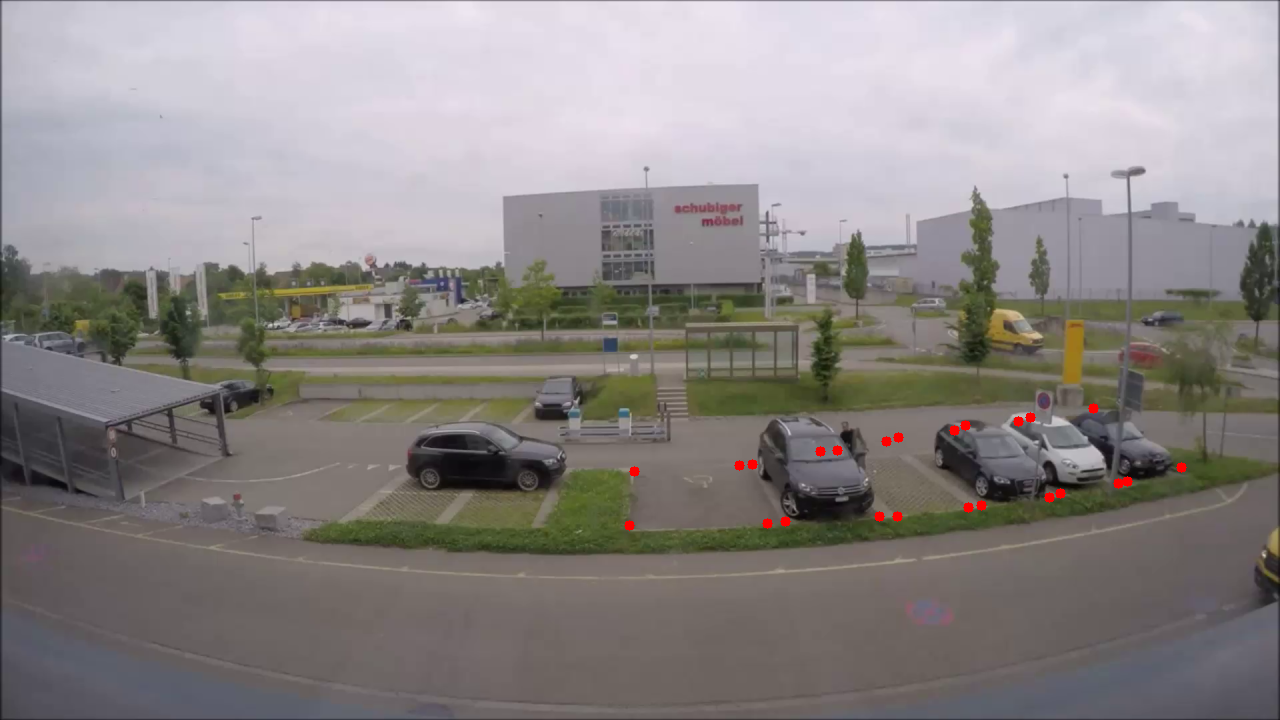

## 6. Cleaning

In [ ]:
# Destroy All Windows

cv2.destroyAllWindows()